# Advanced Behavioral Biometric Feature Analysis (V2)

This notebook explores the extraction of advanced statistical and parametric features from Keystroke and Mouse Trajectory (KMT) data. The goal is to build a robust 'behavioral fingerprint' for user identification.

## 1. Data Loading and Initial Inspection

We load raw KMT data in JSON format for multiple users. Each dataset contains session details and behavioral logs for both the legitimate user and potential imposters.

In [1]:
import json
import os

# Define the path to the raw JSON directory relative to this notebook
raw_data_path = r'../data_raw/feature_kmt_dataset_Edge_Hill_University_22/feature_kmt_json'

# List of 3 files to load
files_to_load = [
    'raw_kmt_user_0001.json',
    'raw_kmt_user_0002.json',
    'raw_kmt_user_0003.json'
]


# Dictionary to hold the loaded JSON data
users_data = {}

# Load each file
for file_name in files_to_load:
    file_path = os.path.join(raw_data_path, file_name)
    with open(file_path, 'r') as f:
        data = json.load(f)
        users_data[file_name] = data
        print(f"Loaded {file_name} successfully. Primary keys: {list(data.keys())}")


Loaded raw_kmt_user_0001.json successfully. Primary keys: ['details', 'true_data', 'false_data']
Loaded raw_kmt_user_0002.json successfully. Primary keys: ['details', 'true_data', 'false_data']
Loaded raw_kmt_user_0003.json successfully. Primary keys: ['details', 'true_data', 'false_data']


## 2. Exploratory Data Analysis: Dwell Time Distributions

Dwell time (hold time) is a primary biometric indicator. Here we calculate timings from raw events and use Kernel Density Estimation (KDE) to visualize how these distributions vary between different users and sessions.

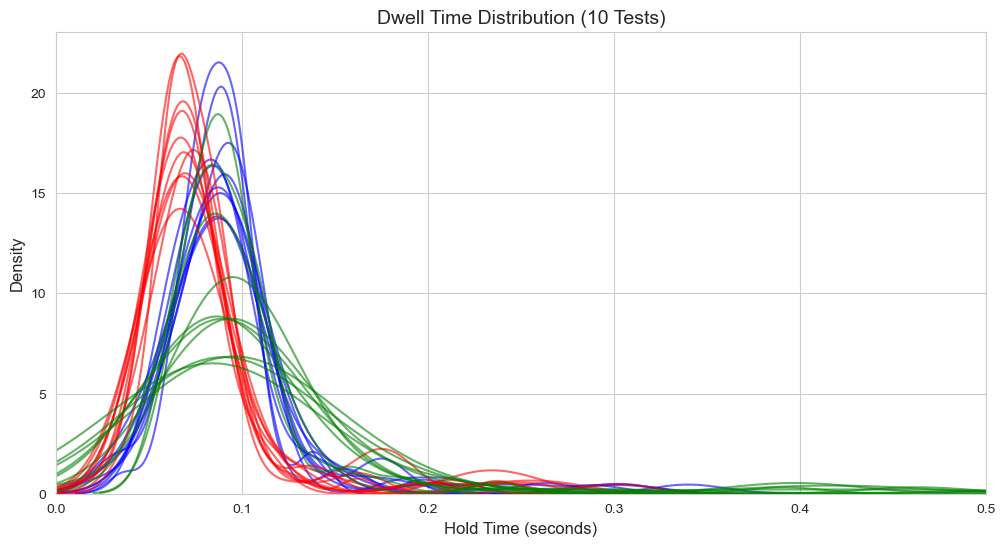

In [2]:
import json
import seaborn as sns
import matplotlib.pyplot as plt


true_data_user_01 = users_data['raw_kmt_user_0001.json']['true_data']
true_data_user_02 = users_data['raw_kmt_user_0002.json']['true_data']
true_data_user_03 = users_data['raw_kmt_user_0003.json']['true_data']

# 2. Function to calculate Dwell Time (Hold Time)
def calculate_dwell_times(events):
    last_press = {}
    dwell_times = []
    for event in events:
        key = event.get('Key')
        event_type = event.get('Event')
        try:
            epoch = float(event.get('Epoch'))
        except (ValueError, TypeError):
            continue
            
        if event_type == 'pressed':
            last_press[key] = epoch
        elif event_type == 'released':
            if key in last_press:
                # Dwell Time = T_release - T_press
                dwell_times.append(epoch - last_press[key])
                del last_press[key]
    return dwell_times

# 3. Setup the Plot
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# 4. Process and Plot each test as a line
# Using a consistent color for all 10 lines
line_color_user_01 = 'blue' 

for test_id in sorted(true_data_user_01.keys()):
    events = true_data_user_01[test_id].get('key_events', [])
    dwell_times = calculate_dwell_times(events)
    
    # Only plot if we have enough data points for a smooth line
    if len(dwell_times) > 1:
        sns.kdeplot(dwell_times, color=line_color_user_01, alpha=0.6, linewidth=1.5, label=test_id)

line_color_user_02 = 'red' 

for test_id in sorted(true_data_user_02.keys()):
    events = true_data_user_02[test_id].get('key_events', [])
    dwell_times = calculate_dwell_times(events)
    
    # Only plot if we have enough data points for a smooth line
    if len(dwell_times) > 1:
        sns.kdeplot(dwell_times, color=line_color_user_02, alpha=0.6, linewidth=1.5, label=test_id)


line_color_user_03 = 'green' 

for test_id in sorted(true_data_user_03.keys()):
    events = true_data_user_03[test_id].get('key_events', [])
    dwell_times = calculate_dwell_times(events)
    
    # Only plot if we have enough data points for a smooth line
    if len(dwell_times) > 1:
        sns.kdeplot(dwell_times, color=line_color_user_03, alpha=0.6, linewidth=1.5, label=test_id)


# 5. Final Formatting
plt.title('Dwell Time Distribution (10 Tests)', fontsize=14)
plt.xlabel('Hold Time (seconds)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.xlim(0, 0.5) # Adjust this limit based on your data range
plt.show()

## 3. Advanced Feature Extraction Pipeline (V2)

The V2 pipeline enhances the feature set by applying:
- **IQR Outlier Filtering**: To remove noise from distractions.
- **Higher-order Statistics**: Capturing distribution shape via Skewness and Kurtosis.
- **Parametric Modeling**: Fitting a Gamma distribution to extract stable shape and scale parameters.

In [3]:
from sympy.parsing.sympy_parser import null
import numpy as np
from scipy import stats
from IPython.display import display
import pandas as pd

def extract_biometric_features(dwell_times):
    data = np.array(dwell_times)
    
    # 1. IQR Filtering to remove outliers
    if len(data) > 4:  # Need sufficient data to calculate quartiles meaningfully
        q1, q3 = np.percentile(data, [25, 75])
        iqr = q3 - q1
        lower_bound = q1 - (1.5 * iqr)
        upper_bound = q3 + (1.5 * iqr)
        
        # Keep only data within the "reasonable" human range
        # Also ensure we don't allow negative dwell times
        cleaned_data = data[(data >= max(0, lower_bound)) & (data <= upper_bound)]
    else:
        cleaned_data = data # Not enough data to filter, proceed as is

    # Fallback if cleaning leaves us with no data
    if len(cleaned_data) == 0:
        return {
            "mean": np.nan, "std": np.nan, "skew": np.nan,
            "kurtosis": np.nan, "gamma_shape": np.nan, "gamma_scale": np.nan
        }

    # 2. Calculate Stats on CLEANED data
    mean_val = np.mean(cleaned_data)
    std_dev = np.std(cleaned_data)
    skewness = stats.skew(cleaned_data)
    kurtosis = stats.kurtosis(cleaned_data)
    
    # 3. Parametric Fitting (Gamma) on CLEANED data
    try:
        # Fitting on cleaned data will produce much more stable shape/scale values
        shape, loc, scale = stats.gamma.fit(cleaned_data, floc=0) 
    except:
        shape, loc, scale = np.nan, np.nan, np.nan
        
    return {
        "mean": mean_val,
        "std": std_dev,
        "skew": skewness,
        "kurtosis": kurtosis,
        "gamma_shape": shape,
        "gamma_scale": scale
    }


def extracted_function(true_data_user_01, calculate_dwell_times, extract_biometric_features, all_test_features):
    # Loop through tests 1 to 10
    for i in range(1, 11):
        test_key = f'test_{i}' # Formats as 'test_1', 'test_2', ..., 'test_10'
    
        # Check if the test key exists in the user's data
        if test_key in true_data_user_01:
            events = true_data_user_01[test_key].get('key_events', [])
    
            # Calculate dwell times (assuming calculate_dwell_times is defined earlier in your notebook)
            dwell_times = calculate_dwell_times(events)
    
            # Extract features
            features = extract_biometric_features(dwell_times)
    
            # Add the test name to the dictionary so we can identify it in the DataFrame
            features['test_id'] = test_key
    
            # Append to our list
            all_test_features.append(features)
        else:
            print(f"Warning: {test_key} not found in the data.")

# Create an empty list to store the features for all tests
all_test_features_user_01 = []
all_test_features_user_02 = []
all_test_features_user_03 = []

extracted_function(true_data_user_01, calculate_dwell_times, extract_biometric_features, all_test_features_user_01)
extracted_function(true_data_user_02, calculate_dwell_times, extract_biometric_features, all_test_features_user_02)
extracted_function(true_data_user_03, calculate_dwell_times, extract_biometric_features, all_test_features_user_03)




# Convert the list of all test features into a single pandas DataFrame
def to_data_frame_to_display(all_test_features):
    df_features = pd.DataFrame(all_test_features)

    # Move 'test_id' to be the first column for better readability
    if not df_features.empty:
        cols = ['test_id'] + [col for col in df_features.columns if col != 'test_id']
        df_features = df_features[cols]

    return df_features

df_features_user_01 = to_data_frame_to_display(all_test_features_user_01)
df_features_user_02 = to_data_frame_to_display(all_test_features_user_02)
df_features_user_03 = to_data_frame_to_display(all_test_features_user_03)


# Display the final DataFrame containing all tests
print("User 01")
display(df_features_user_01)

print("User 02")
display(df_features_user_02)

print("User 03")
display(df_features_user_03)

User 01


,test_id,mean,std,skew,kurtosis,gamma_shape,gamma_scale
0,test_1,0.086414,0.016220,-0.049620,-0.940319,27.332493,0.003162
1,test_2,0.085432,0.013853,-0.231369,-0.665543,36.094959,0.002367
2,test_3,0.087346,0.017016,-0.272503,-0.387325,24.226644,0.003605
3,test_4,0.087753,0.015966,-0.524898,-0.538410,27.260723,0.003219
4,test_5,0.082297,0.017404,0.189877,-0.367492,21.852163,0.003766
5,test_6,0.083867,0.014898,-0.066401,-0.471046,30.292108,0.002769
6,test_7,0.086171,0.013198,-0.093089,-0.785274,41.259803,0.002088
7,test_8,0.086997,0.014895,-0.242027,-0.177354,31.846139,0.002732
8,test_9,0.085313,0.016768,-0.158629,-0.063723,24.042699,0.003548
9,test_10,0.087589,0.015151,-0.165292,0.121525,31.304305,0.002798


User 02


,test_id,mean,std,skew,kurtosis,gamma_shape,gamma_scale
0,test_1,0.071398,0.014607,-0.614503,0.419133,20.028953,0.003565
1,test_2,0.072321,0.015208,0.134649,0.016679,21.582247,0.003351
2,test_3,0.067845,0.011095,0.038093,-0.570819,36.481668,0.001860
3,test_4,0.067155,0.009243,0.256988,-0.197287,52.795247,0.001272
4,test_5,0.069014,0.011645,0.077453,-0.968121,34.549483,0.001998
5,test_6,0.068447,0.008689,-0.084852,-0.457639,60.461276,0.001132
6,test_7,0.067350,0.010666,0.129878,-0.597142,39.382608,0.001710
7,test_8,0.067759,0.011089,0.169574,-0.559190,36.966916,0.001833
8,test_9,0.068784,0.010978,-0.166460,-0.688769,37.549721,0.001832
9,test_10,0.066751,0.008215,0.832785,0.816764,69.114212,0.000966


User 03


,test_id,mean,std,skew,kurtosis,gamma_shape,gamma_scale
0,test_1,0.097743,0.018055,0.904174,0.430725,31.498959,0.003103
1,test_2,0.098497,0.026710,0.704041,-0.171207,14.369917,0.006854
2,test_3,0.087363,0.016604,0.088348,-1.091334,27.189240,0.003213
3,test_4,0.086329,0.015487,0.438003,0.740114,31.011190,0.002784
4,test_5,0.087043,0.014567,0.324742,0.356080,35.605942,0.002445
5,test_6,0.086688,0.015140,0.301472,-0.453331,32.891169,0.002636
6,test_7,0.092507,0.023475,1.250193,0.956118,17.848311,0.005183
7,test_8,0.095000,0.021703,0.332292,-0.399321,19.079414,0.004979
8,test_9,0.090582,0.017371,0.619535,-0.384314,28.376101,0.003192
9,test_10,0.084786,0.013752,0.775603,0.294564,40.097987,0.002114


## 4 colparition the varible with orginal data

In [4]:
import numpy as np
from scipy.stats import gamma

# Helper to get average parameters for a user
def get_average_gamma_params(features_list):
    # Filter out NaNs to ensure the average is accurate
    valid_shapes = [f['gamma_shape'] for f in features_list if not np.isnan(f['gamma_shape'])]
    valid_scales = [f['gamma_scale'] for f in features_list if not np.isnan(f['gamma_scale'])]
    
    return np.mean(valid_shapes), np.mean(valid_scales)

# Calculate for all three users
avg_shape_1, avg_scale_1 = get_average_gamma_params(all_test_features_user_01)
avg_shape_2, avg_scale_2 = get_average_gamma_params(all_test_features_user_02)
avg_shape_3, avg_scale_3 = get_average_gamma_params(all_test_features_user_03)

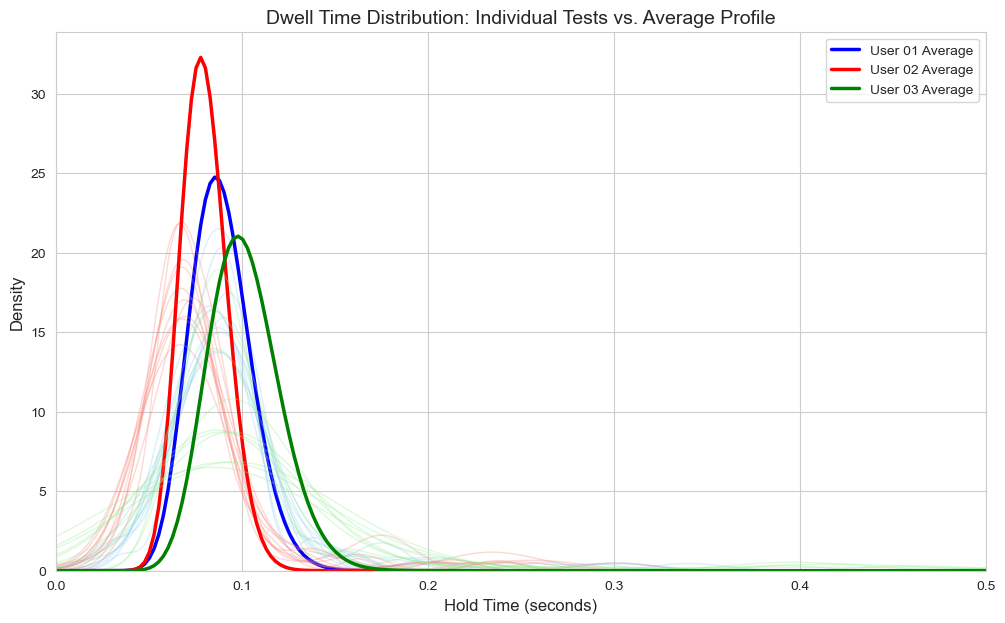

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

# Define users, their data, and their specific colors
users_config = [
    {'data': true_data_user_01, 'shape': avg_shape_1, 'scale': avg_scale_1, 'light': 'skyblue', 'dark': 'blue', 'label': 'User 01'},
    {'data': true_data_user_02, 'shape': avg_shape_2, 'scale': avg_scale_2, 'light': 'salmon', 'dark': 'red', 'label': 'User 02'},
    {'data': true_data_user_03, 'shape': avg_shape_3, 'scale': avg_scale_3, 'light': 'lightgreen', 'dark': 'green', 'label': 'User 03'},
]

x = np.linspace(0, 0.5, 200) # Range for dwell time

for config in users_config:
    # A. Plot Light Distributions (Individual Tests)
    for test_id in sorted(config['data'].keys()):
        events = config['data'][test_id].get('key_events', [])
        dwell_times = calculate_dwell_times(events)
        if len(dwell_times) > 1:
            sns.kdeplot(dwell_times, color=config['light'], alpha=0.3, linewidth=1)
            
    # B. Plot Dark Average Line (Calculated Gamma PDF)
    # Using the averaged parameters computed above
    y_avg = gamma.pdf(x, a=config['shape'], loc=0, scale=config['scale'])
    plt.plot(x, y_avg, color=config['dark'], linewidth=2.5, label=f'{config["label"]} Average')

plt.title('Dwell Time Distribution: Individual Tests vs. Average Profile', fontsize=14)
plt.xlabel('Hold Time (seconds)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.xlim(0, 0.5)
plt.legend()
plt.show()

## 5. Advanced Feature Extraction Pipeline (Authentication-Ready)

Here we move from simple descriptive statistics to an authentication-ready schema. We extract advanced features including gamma distribution parameters, moments, Shannon entropy, and digraph profiles.

In [6]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import math

def extract_advanced_features(dwell_times, events):
    """
    Extract advanced features from dwell times and events.
    """
    features = {}
    
    # 1. Gamma params
    if len(dwell_times) > 0:
        shape, loc, scale = stats.gamma.fit(dwell_times, floc=0)
        features["gamma_params"] = {"shape": shape, "scale": scale}
    else:
        features["gamma_params"] = {"shape": 0.0, "scale": 0.0}
        
    # 2. Moments
    if len(dwell_times) > 0:
        features["moments"] = {
            "mean": float(np.mean(dwell_times)),
            "std": float(np.std(dwell_times)),
            "skew": float(stats.skew(dwell_times)) if len(dwell_times) > 2 else 0.0,
            "kurtosis": float(stats.kurtosis(dwell_times)) if len(dwell_times) > 3 else 0.0
        }
    else:
        features["moments"] = {"mean": 0.0, "std": 0.0, "skew": 0.0, "kurtosis": 0.0}
        
    # 3. n_samples
    features["n_samples"] = len(dwell_times)
    
    # 4. timestamp (unix epoch) - from first event if available
    if events:
        try:
            ts = float(events[0].get('Epoch', 0))
        except (ValueError, TypeError):
            ts = 0.0
        features["timestamp"] = ts
    else:
        features["timestamp"] = 0.0
    
    # 5. entropy
    if len(dwell_times) > 0:
        # Calculate Shannon entropy using a histogram approach
        counts, _ = np.histogram(dwell_times, bins='auto')
        probs = counts / counts.sum()
        entropy = -np.sum(p * np.log2(p) for p in probs if p > 0)
        features["entropy"] = float(entropy)
    else:
        features["entropy"] = 0.0
        
    # 6. digraph_profile
    digraph_profile = {}
    if len(events) >= 2:
        digraphs = {}
        for i in range(len(events) - 1):
            if events[i].get('Event') == 'pressed' and events[i+1].get('Event') == 'pressed':
                key1 = events[i].get('Key', '')
                key2 = events[i+1].get('Key', '')
                try:
                    epoch1 = float(events[i].get('Epoch', 0))
                    epoch2 = float(events[i+1].get('Epoch', 0))
                except (ValueError, TypeError):
                    continue
                    
                if key1 and key2:
                    pair = f"{key1}-{key2}"
                    latency = epoch2 - epoch1
                    if pair not in digraphs:
                        digraphs[pair] = []
                    digraphs[pair].append(latency)
        
        # Calculate averages for each pair
        avg_digraphs = {pair: np.mean(latencies) for pair, latencies in digraphs.items()}
        # Get top 5 most common pairs based on frequency
        sorted_pairs = sorted(digraphs.keys(), key=lambda k: len(digraphs[k]), reverse=True)[:5]
        digraph_profile = {pair: float(avg_digraphs[pair]) for pair in sorted_pairs}
        
    features["digraph_profile"] = digraph_profile
    
    return features

In [7]:
# Process all test files for 3 users into a list of dictionaries following the schema above.
processed_data = []

def get_dwell_times(events):
    last_press = {}
    dwell_times = []
    for event in events:
        key = event.get('Key')
        event_type = event.get('Event')
        try:
            epoch = float(event.get('Epoch'))
        except (ValueError, TypeError):
            continue
            
        if event_type == 'pressed':
            last_press[key] = epoch
        elif event_type == 'released':
            if key in last_press:
                dwell = epoch - last_press[key]
                if 0 < dwell < 5: # filter out anomalies (seconds)
                    dwell_times.append(dwell)
                del last_press[key]
    return dwell_times

for user_id, data in users_data.items():
    # Process true_data
    for session_idx, session in data.get('true_data', {}).items():
        events = session.get('key_events', [])
        dwell_times = get_dwell_times(events)
        
        features = extract_advanced_features(dwell_times, events)
        features['user'] = user_id
        features['label'] = 1 # Legitimate
        features['session'] = session_idx
        processed_data.append(features)
        
    # Process false_data
    for session_idx, session in data.get('false_data', {}).items():
        events = session.get('key_events', [])
        dwell_times = get_dwell_times(events)
                    
        features = extract_advanced_features(dwell_times, events)
        features['user'] = user_id
        features['label'] = 0 # Imposter
        features['session'] = session_idx
        processed_data.append(features)

# Convert these lists into a flattened pandas DataFrame
flattened_data = []
for row in processed_data:
    flat_row = {
        'user': row['user'],
        'label': row['label'],
        'session': row['session'],
        'gamma_shape': row['gamma_params']['shape'],
        'gamma_scale': row['gamma_params']['scale'],
        'moment_mean': row['moments']['mean'],
        'moment_std': row['moments']['std'],
        'moment_skew': row['moments']['skew'],
        'moment_kurtosis': row['moments']['kurtosis'],
        'n_samples': row['n_samples'],
        'timestamp': row['timestamp'],
        'entropy': row['entropy']
    }
    # Add digraphs
    for i, (pair, latency) in enumerate(row['digraph_profile'].items()):
        flat_row[f'digraph_{i+1}_pair'] = pair
        flat_row[f'digraph_{i+1}_latency'] = latency
        
    flattened_data.append(flat_row)

df_advanced_features = pd.DataFrame(flattened_data)
display(df_advanced_features.head())

C:\Users\Ravin\AppData\Local\Temp\ipykernel_23860\1791435163.py:48: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  entropy = -np.sum(p * np.log2(p) for p in probs if p > 0)


,user,label,session,gamma_shape,gamma_scale,moment_mean,moment_std,moment_skew,moment_kurtosis,n_samples,...,digraph_1_pair,digraph_1_latency,digraph_2_pair,digraph_2_latency,digraph_3_pair,digraph_3_latency,digraph_4_pair,digraph_4_latency,digraph_5_pair,digraph_5_latency
0,raw_kmt_user_0001.json,1,test_1,9.506793,0.009818,0.093341,0.036234,3.078586,13.251395,57,...,shift-m,0.094777,spacebar-shift,0.073022,w-e,0.000000,shift-e,0.176325,l-i,0.125325
1,raw_kmt_user_0001.json,1,test_2,11.734102,0.007249,0.085055,0.023216,0.384579,2.474012,50,...,shift-m,0.081046,shift-e,0.062469,l-i,0.049065,i-e,0.086411,8-9,0.049091
2,raw_kmt_user_0001.json,1,test_3,9.157411,0.009974,0.091337,0.029751,0.900688,1.988247,50,...,shift-m,0.081669,shift-e,0.076365,l-i,0.124784,l-e,0.049181,8-9,0.063076
3,raw_kmt_user_0001.json,1,test_4,10.260792,0.008907,0.091395,0.029832,1.830122,6.366527,44,...,shift-m,0.108630,shift-e,0.086512,l-i,0.076167,l-e,0.076149,8-9,0.061542
4,raw_kmt_user_0001.json,1,test_5,12.758214,0.006866,0.087598,0.026871,1.779152,4.793167,45,...,shift-m,0.106731,shift-e,0.037032,l-i,0.098616,spacebar-m,0.061413,l-e,0.061384


C:\Users\Ravin\AppData\Local\Temp\ipykernel_23860\1791435163.py:48: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  entropy = -np.sum(p * np.log2(p) for p in probs if p > 0)


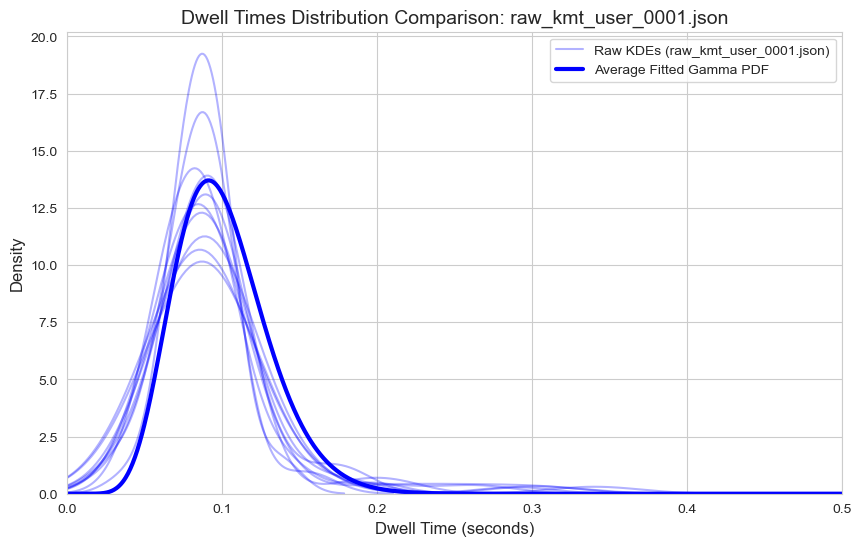

C:\Users\Ravin\AppData\Local\Temp\ipykernel_23860\1791435163.py:48: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  entropy = -np.sum(p * np.log2(p) for p in probs if p > 0)


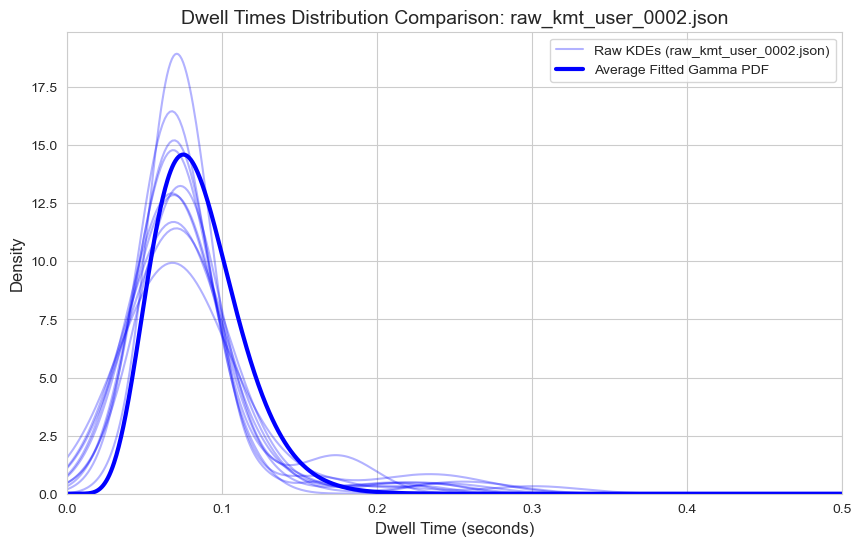

C:\Users\Ravin\AppData\Local\Temp\ipykernel_23860\1791435163.py:48: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  entropy = -np.sum(p * np.log2(p) for p in probs if p > 0)


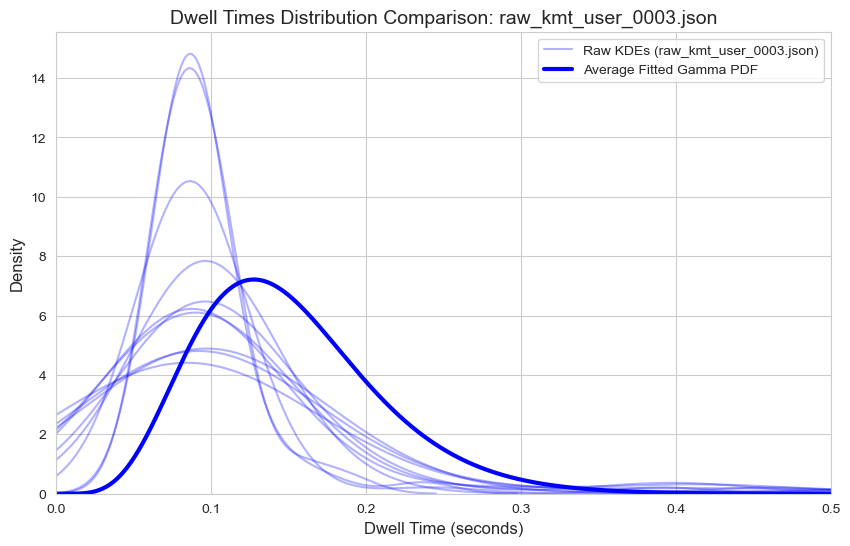

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as stats

def plot_user_sessions(user_sessions_dwells, avg_shape, avg_scale, user_label):
    """
    Plots a comparison of 10 raw test KDEs and the averaged fitted Gamma PDF for a user.
    """
    plt.figure(figsize=(10, 6))
    sns.set_style("whitegrid")
    
    # a) Faint KDE plots of all raw dwell_times
    for dwell_times in user_sessions_dwells:
        if len(dwell_times) > 1:
            sns.kdeplot(dwell_times, color='blue', alpha=0.3, linewidth=1.5, bw_adjust=1.5)
            
    # Add an empty proxy artist for the KDE legend
    plt.plot([], [], color='blue', alpha=0.3, linewidth=1.5, label=f'Raw KDEs ({user_label})')
    
    # b) Bold line plot (using scipy.stats.gamma.pdf)
    x = np.linspace(0, 0.5, 1000)
    if avg_shape > 0 and avg_scale > 0:
        pdf_fitted = stats.gamma.pdf(x, a=avg_shape, scale=avg_scale)
        plt.plot(x, pdf_fitted, color='blue', linewidth=3, label='Average Fitted Gamma PDF')
    
    plt.title(f'Dwell Times Distribution Comparison: {user_label}', fontsize=14)
    plt.xlabel('Dwell Time (seconds)', fontsize=12)
    plt.ylabel('Density', fontsize=12)
    plt.xlim(0, 0.5)
    plt.legend()
    plt.show()

# Plot a comparison for all sessions of each user
for user_id in users_data.keys():
    user_sessions_dwells = []
    shapes = []
    scales = []
    
    for session_key, session_data in users_data[user_id]['true_data'].items():
        session_events = session_data.get('key_events', [])
        dwell_times = get_dwell_times(session_events)
        
        if len(dwell_times) > 0:
            user_sessions_dwells.append(dwell_times)
            features = extract_advanced_features(dwell_times, session_events)
            shapes.append(features['gamma_params']['shape'])
            scales.append(features['gamma_params']['scale'])
            
    avg_shape = np.mean(shapes) if shapes else 0
    avg_scale = np.mean(scales) if scales else 0
    
    plot_user_sessions(user_sessions_dwells, avg_shape, avg_scale, user_id)


## 6. Privacy-Preserving Numerical Transformation

In behavioral authentication, logging the actual keys typed (like `shift-m`) is considered highly sensitive and acts like a privacy-invasive keylogger. To build a secure and privacy-preserving machine learning model, we will:
1. Drop the explicit keystroke combinations (`digraph_X_pair`) and only keep the behavioral timings (`digraph_X_latency`).
2. Map the string identifiers for `user` and `session` to clean integer IDs.

In [9]:
# Create a copy to preserve the original dataframe
df_clean = df_advanced_features.copy()

# 1. Drop sensitive keystroke pair strings
pair_columns = [col for col in df_clean.columns if 'pair' in col]
df_clean = df_clean.drop(columns=pair_columns)

# 2. Convert 'user' strings to numerical IDs (e.g., 'raw_kmt_user_0001.json' -> 1)
df_clean['user'] = df_clean['user'].str.extract(r'(\d+)').astype(int)

# 3. Convert 'session' strings to numerical IDs (e.g., 'test_1' -> 1)
df_clean['session'] = df_clean['session'].str.extract(r'(\d+)').astype(int)

# 4. Convert label to int (just in case)
df_clean['label'] = df_clean['label'].astype(int)

display(df_clean.head())
print("\nDataset Information:")
display(df_clean.info())


,user,label,session,gamma_shape,gamma_scale,moment_mean,moment_std,moment_skew,moment_kurtosis,n_samples,timestamp,entropy,digraph_1_latency,digraph_2_latency,digraph_3_latency,digraph_4_latency,digraph_5_latency
0,1,1,1,9.506793,0.009818,0.093341,0.036234,3.078586,13.251395,57,1.644174e+09,2.847763,0.094777,0.073022,0.000000,0.176325,0.125325
1,1,1,2,11.734102,0.007249,0.085055,0.023216,0.384579,2.474012,50,1.644174e+09,2.619067,0.081046,0.062469,0.049065,0.086411,0.049091
2,1,1,3,9.157411,0.009974,0.091337,0.029751,0.900688,1.988247,50,1.644174e+09,2.719538,0.081669,0.076365,0.124784,0.049181,0.063076
3,1,1,4,10.260792,0.008907,0.091395,0.029832,1.830122,6.366527,44,1.644174e+09,2.584974,0.108630,0.086512,0.076167,0.076149,0.061542
4,1,1,5,12.758214,0.006866,0.087598,0.026871,1.779152,4.793167,45,1.644174e+09,2.562721,0.106731,0.037032,0.098616,0.061413,0.061384



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   user               60 non-null     int32  
 1   label              60 non-null     int32  
 2   session            60 non-null     int32  
 3   gamma_shape        60 non-null     float64
 4   gamma_scale        60 non-null     float64
 5   moment_mean        60 non-null     float64
 6   moment_std         60 non-null     float64
 7   moment_skew        60 non-null     float64
 8   moment_kurtosis    60 non-null     float64
 9   n_samples          60 non-null     int64  
 10  timestamp          60 non-null     float64
 11  entropy            60 non-null     float64
 12  digraph_1_latency  58 non-null     float64
 13  digraph_2_latency  58 non-null     float64
 14  digraph_3_latency  52 non-null     float64
 15  digraph_4_latency  38 non-null     float64
 16  digrap

None

## 7. Comparative Distribution: Raw Tests vs. Extracted Gamma PDF

Here we visualize how closely our extracted statistical features match the real-world data. We plot the individual test KDEs as faint lines, and we draw the bold lines using the mathematical **Gamma PDF** derived by averaging the `gamma_shape` and `gamma_scale` extracted in our DataFrame.

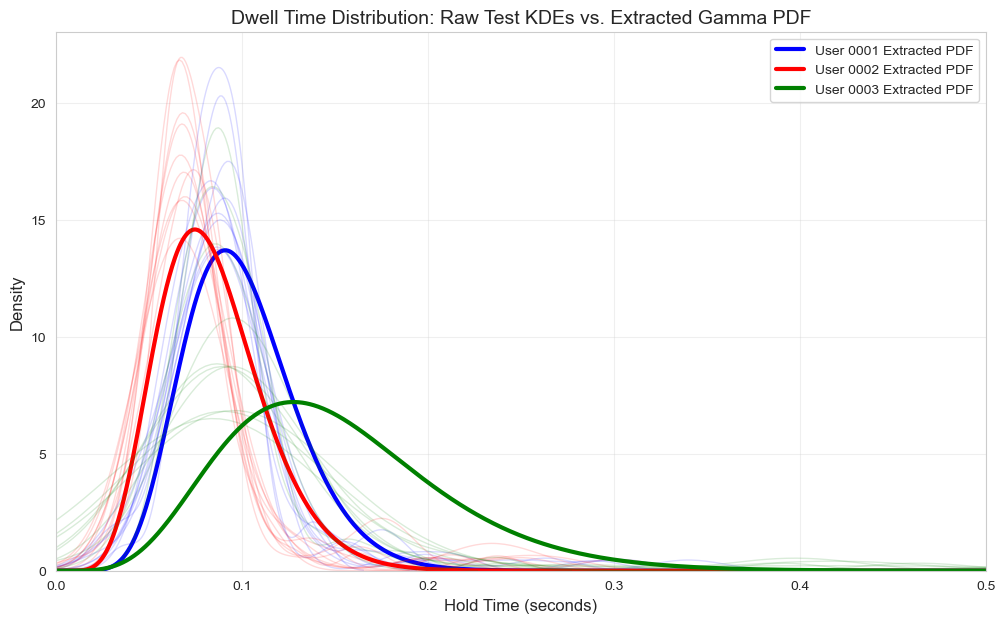

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import numpy as np

plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

colors = ['blue', 'red', 'green']

# Loop through each user and plot
for i, (user_id, data) in enumerate(users_data.items()):
    color = colors[i % len(colors)]
    
    # 1. Plot individual test KDE (faint lines)
    for session_idx, session in data.get('true_data', {}).items():
        events = session.get('key_events', [])
        dwell_times = get_dwell_times(events)
        
        if len(dwell_times) > 1:
            sns.kdeplot(dwell_times, color=color, alpha=0.15, linewidth=1)
            
    # 2. Plot the extracted Gamma PDF (bold line) from our dataframe features
    # Filter the dataframe for this user's true_data (label == 1)
    user_df = df_advanced_features[(df_advanced_features['user'] == user_id) & (df_advanced_features['label'] == 1)]
    
    if not user_df.empty:
        # Average the extracted Gamma parameters
        avg_shape = user_df['gamma_shape'].mean()
        avg_scale = user_df['gamma_scale'].mean()
        
        # Draw the PDF
        x = np.linspace(0, 0.5, 1000)
        if avg_shape > 0 and avg_scale > 0:
            pdf_fitted = stats.gamma.pdf(x, a=avg_shape, scale=avg_scale)
            
            # Format user label
            import re
            match = re.search(r'(\d+)', user_id)
            user_num = match.group(1) if match else str(i+1)
            
            plt.plot(x, pdf_fitted, color=color, linewidth=3, label=f'User {user_num} Extracted PDF')

plt.title('Dwell Time Distribution: Raw Test KDEs vs. Extracted Gamma PDF', fontsize=14)
plt.xlabel('Hold Time (seconds)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.xlim(0, 0.5)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 8. The Final Robust Pipeline (V3)

Having identified the vulnerability of our parametric models to outliers (like User 3's distractions), we now combine everything into the final, robust pipeline.

Key improvements in this final pass:
1. **IQR Outlier Filtering:** We dynamically filter out extreme dwell times (Q3 + 1.5*IQR) for each session before fitting the Gamma distribution.
2. **Privacy-Preservation:** We immediately drop sensitive string features (like specific keystrokes) and generate a strictly numerical, 17-column DataFrame.
3. **Verification Plot:** We re-plot the KDEs vs. Extracted Gamma PDFs to demonstrate how removing outliers fixes User 3's skewed distribution.


Final Privacy-Preserving Dataset:


C:\Users\Ravin\AppData\Local\Temp\ipykernel_23860\3638841235.py:48: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  entropy = -np.sum(p * np.log2(p) for p in probs if p > 0)


,user,label,session,gamma_shape,gamma_scale,moment_mean,moment_std,moment_skew,moment_kurtosis,n_samples,timestamp,entropy,digraph_1_latency,digraph_2_latency,digraph_3_latency,digraph_4_latency,digraph_5_latency
0,1,1,1,21.445185,0.003985,0.085463,0.017466,-0.328052,-0.281709,53,1.644174e+09,2.323039,0.094777,0.073022,0.000000,0.176325,0.125325
1,1,1,2,14.426824,0.005693,0.082130,0.018595,-1.043213,1.156929,48,1.644174e+09,2.354183,0.081046,0.062469,0.049065,0.086411,0.049091
2,1,1,3,13.225596,0.006417,0.084864,0.020361,-0.784331,0.666477,46,1.644174e+09,2.576847,0.081669,0.076365,0.124784,0.049181,0.063076
3,1,1,4,16.299128,0.005292,0.086250,0.018478,-1.035106,1.205044,42,1.644174e+09,2.359978,0.108630,0.086512,0.076167,0.076149,0.061542
4,1,1,5,21.852163,0.003766,0.082297,0.017404,0.189877,-0.367492,42,1.644174e+09,2.433114,0.106731,0.037032,0.098616,0.061413,0.061384


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   user               60 non-null     int32  
 1   label              60 non-null     int32  
 2   session            60 non-null     int32  
 3   gamma_shape        60 non-null     float64
 4   gamma_scale        60 non-null     float64
 5   moment_mean        60 non-null     float64
 6   moment_std         60 non-null     float64
 7   moment_skew        60 non-null     float64
 8   moment_kurtosis    60 non-null     float64
 9   n_samples          60 non-null     int64  
 10  timestamp          60 non-null     float64
 11  entropy            60 non-null     float64
 12  digraph_1_latency  58 non-null     float64
 13  digraph_2_latency  58 non-null     float64
 14  digraph_3_latency  52 non-null     float64
 15  digraph_4_latency  38 non-null     float64
 16  digraph_5_latency  27 non-nu

None

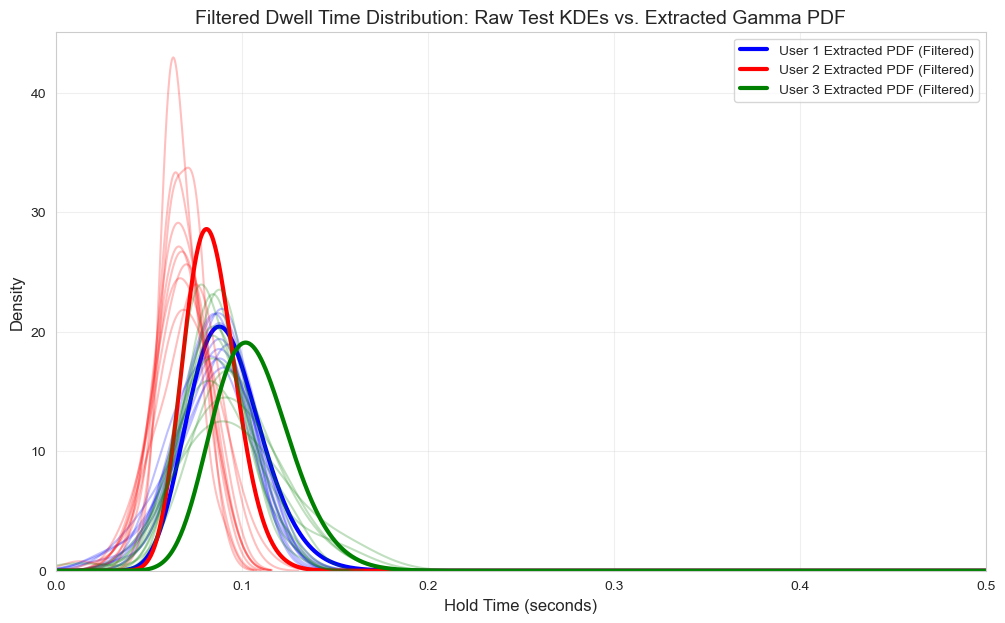

In [11]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import math
import re

# --- 1. Advanced Feature Extraction ---
def extract_advanced_features_v3(dwell_times, events):
    features = {}
    
    # 1. Gamma params
    if len(dwell_times) > 0:
        shape, loc, scale = stats.gamma.fit(dwell_times, floc=0)
        features["gamma_params"] = {"shape": shape, "scale": scale}
    else:
        features["gamma_params"] = {"shape": 0.0, "scale": 0.0}
        
    # 2. Moments
    if len(dwell_times) > 0:
        features["moments"] = {
            "mean": float(np.mean(dwell_times)),
            "std": float(np.std(dwell_times)),
            "skew": float(stats.skew(dwell_times)) if len(dwell_times) > 2 else 0.0,
            "kurtosis": float(stats.kurtosis(dwell_times)) if len(dwell_times) > 3 else 0.0
        }
    else:
        features["moments"] = {"mean": 0.0, "std": 0.0, "skew": 0.0, "kurtosis": 0.0}
        
    # 3. n_samples
    features["n_samples"] = len(dwell_times)
    
    # 4. timestamp (unix epoch)
    if events:
        try:
            ts = float(events[0].get('Epoch', 0))
        except (ValueError, TypeError):
            ts = 0.0
        features["timestamp"] = ts
    else:
        features["timestamp"] = 0.0
    
    # 5. entropy
    if len(dwell_times) > 0:
        counts, _ = np.histogram(dwell_times, bins='auto')
        probs = counts / counts.sum()
        entropy = -np.sum(p * np.log2(p) for p in probs if p > 0)
        features["entropy"] = float(entropy)
    else:
        features["entropy"] = 0.0
        
    # 6. digraph_profile (Privacy Preserving - Latency Only)
    digraph_latencies = []
    if len(events) >= 2:
        digraphs = {}
        for i in range(len(events) - 1):
            if events[i].get('Event') == 'pressed' and events[i+1].get('Event') == 'pressed':
                key1 = events[i].get('Key', '')
                key2 = events[i+1].get('Key', '')
                try:
                    epoch1 = float(events[i].get('Epoch', 0))
                    epoch2 = float(events[i+1].get('Epoch', 0))
                except (ValueError, TypeError):
                    continue
                    
                if key1 and key2:
                    pair = f"{key1}-{key2}"
                    latency = epoch2 - epoch1
                    if pair not in digraphs:
                        digraphs[pair] = []
                    digraphs[pair].append(latency)
        
        avg_digraphs = {pair: np.mean(latencies) for pair, latencies in digraphs.items()}
        sorted_pairs = sorted(digraphs.keys(), key=lambda k: len(digraphs[k]), reverse=True)[:5]
        digraph_latencies = [float(avg_digraphs[pair]) for pair in sorted_pairs]
        
    features["digraph_latencies"] = digraph_latencies
    return features


# --- 2. Dwell Time Parsing with IQR Filtering ---
def get_filtered_dwell_times(events):
    last_press = {}
    raw_dwell_times = []
    for event in events:
        key = event.get('Key')
        event_type = event.get('Event')
        try:
            epoch = float(event.get('Epoch'))
        except (ValueError, TypeError):
            continue
            
        if event_type == 'pressed':
            last_press[key] = epoch
        elif event_type == 'released':
            if key in last_press:
                dwell = epoch - last_press[key]
                if 0 < dwell < 5: # Basic sanity filter
                    raw_dwell_times.append(dwell)
                del last_press[key]
                
    # Apply IQR Outlier Filtering
    if len(raw_dwell_times) > 4:
        q1 = np.percentile(raw_dwell_times, 25)
        q3 = np.percentile(raw_dwell_times, 75)
        iqr = q3 - q1
        upper_bound = q3 + 1.5 * iqr
        
        filtered_dwell_times = [d for d in raw_dwell_times if d <= upper_bound]
        return filtered_dwell_times
    
    return raw_dwell_times

# --- 3. Run Pipeline ---
processed_data_v3 = []

# To store filtered dwell times for plotting later
filtered_dwell_times_dict = {}

for user_id, data in users_data.items():
    filtered_dwell_times_dict[user_id] = {}
    
    # Process true_data
    for session_idx, session in data.get('true_data', {}).items():
        events = session.get('key_events', [])
        dwell_times = get_filtered_dwell_times(events)
        
        # Save for plotting
        filtered_dwell_times_dict[user_id][session_idx] = dwell_times
        
        features = extract_advanced_features_v3(dwell_times, events)
        features['user'] = user_id
        features['label'] = 1
        features['session'] = session_idx
        processed_data_v3.append(features)
        
    # Process false_data
    for session_idx, session in data.get('false_data', {}).items():
        events = session.get('key_events', [])
        dwell_times = get_filtered_dwell_times(events)
        
        features = extract_advanced_features_v3(dwell_times, events)
        features['user'] = user_id
        features['label'] = 0
        features['session'] = session_idx
        processed_data_v3.append(features)

# Convert to DataFrame
flattened_data_v3 = []
for row in processed_data_v3:
    flat_row = {
        'user': row['user'],
        'label': row['label'],
        'session': row['session'],
        'gamma_shape': row['gamma_params']['shape'],
        'gamma_scale': row['gamma_params']['scale'],
        'moment_mean': row['moments']['mean'],
        'moment_std': row['moments']['std'],
        'moment_skew': row['moments']['skew'],
        'moment_kurtosis': row['moments']['kurtosis'],
        'n_samples': row['n_samples'],
        'timestamp': row['timestamp'],
        'entropy': row['entropy']
    }
    
    # Add privacy-preserving digraph latencies
    for i in range(5):
        val = row['digraph_latencies'][i] if i < len(row['digraph_latencies']) else np.nan
        flat_row[f'digraph_{i+1}_latency'] = val
        
    flattened_data_v3.append(flat_row)

df_final = pd.DataFrame(flattened_data_v3)

# Map strings to integers
df_final['user'] = df_final['user'].str.extract(r'(\d+)').astype(int)
df_final['session'] = df_final['session'].str.extract(r'(\d+)').astype(int)
df_final['label'] = df_final['label'].astype(int)

print("\nFinal Privacy-Preserving Dataset:")
display(df_final.head())
display(df_final.info())

# --- 4. Plot Comparison (Filtered) ---
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")
colors = ['blue', 'red', 'green']

for i, (user_id, sessions_dict) in enumerate(filtered_dwell_times_dict.items()):
    color = colors[i % len(colors)]
    
    # 1. Faint KDEs
    for session_idx, dwell_times in sessions_dict.items():
        if len(dwell_times) > 1:
            sns.kdeplot(dwell_times, color=color, alpha=0.25, linewidth=1.5, bw_adjust=1.5)
            
    # 2. Bold PDF
    user_num = int(re.search(r'(\d+)', user_id).group(1))
    user_df = df_final[(df_final['user'] == user_num) & (df_final['label'] == 1)]
    
    if not user_df.empty:
        avg_shape = user_df['gamma_shape'].mean()
        avg_scale = user_df['gamma_scale'].mean()
        
        x = np.linspace(0, 0.5, 1000)
        if avg_shape > 0 and avg_scale > 0:
            pdf_fitted = stats.gamma.pdf(x, a=avg_shape, scale=avg_scale)
            plt.plot(x, pdf_fitted, color=color, linewidth=3, label=f'User {user_num} Extracted PDF (Filtered)')

plt.title('Filtered Dwell Time Distribution: Raw Test KDEs vs. Extracted Gamma PDF', fontsize=14)
plt.xlabel('Hold Time (seconds)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.xlim(0, 0.5)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 9. Quantitative Evaluation of Outlier Filtering Methods

The goal here is to mathematically prove which outlier removal technique creates the most distinct behavioral fingerprint. We evaluate this using the **Separation Ratio**, which compares:
- **Intra-User Distance (Minimize):** Average Euclidean distance between tests of the *same* user (e.g., User A Test 1 vs User A Test 5).
- **Inter-User Distance (Maximize):** Average Euclidean distance between tests of *different* users (e.g., User A Test 1 vs User B Test 1).

**Best Method:** The method with the highest ratio of (Inter / Intra) creates the most distinct, secure biometric profiles!

C:\Users\Ravin\AppData\Local\Temp\ipykernel_23860\3528515378.py:71: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  entropy = -np.sum(p * np.log2(p) for p in probs if p > 0)
C:\Users\Ravin\AppData\Local\Temp\ipykernel_23860\3528515378.py:71: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  entropy = -np.sum(p * np.log2(p) for p in probs if p > 0)
C:\Users\Ravin\AppData\Local\Temp\ipykernel_23860\3528515378.py:71: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  entropy = -np.sum(p * np.log2(p) for p in probs if p > 0)


,Method,Intra-User Distance (Minimize),Inter-User Distance (Maximize),Separation Ratio (Maximize)
0,No Filter,2.191227,3.104781,1.416914
1,IQR Filter,2.114047,3.079201,1.456543
2,MAD Filter,1.985697,2.988787,1.505158


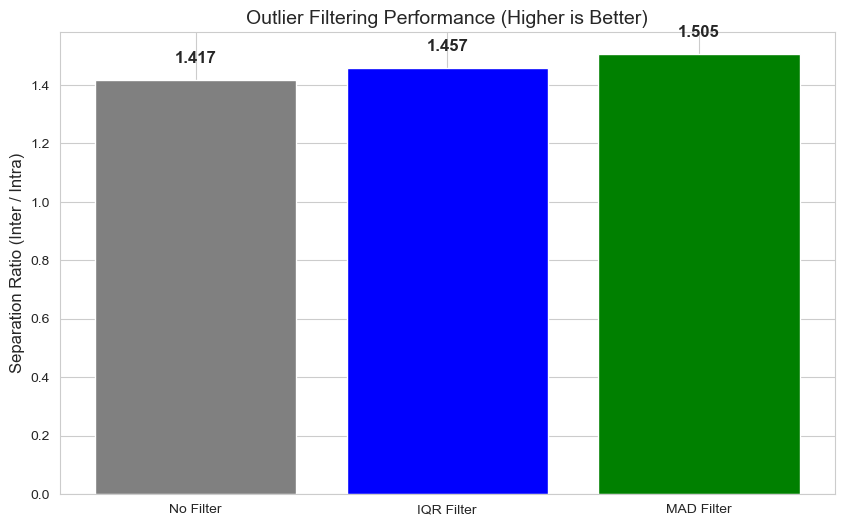

In [12]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform

# 1. Define Outlier Filters
def filter_none(raw_dwells):
    return [d for d in raw_dwells if 0 < d < 5]

def filter_iqr(raw_dwells):
    valid = [d for d in raw_dwells if 0 < d < 5]
    if len(valid) > 4:
        q1, q3 = np.percentile(valid, [25, 75])
        upper = q3 + 1.5 * (q3 - q1)
        return [d for d in valid if d <= upper]
    return valid

def filter_mad(raw_dwells):
    valid = [d for d in raw_dwells if 0 < d < 5]
    if len(valid) > 4:
        median = np.median(valid)
        mad = np.median([np.abs(d - median) for d in valid])
        # 3*MAD is a highly robust threshold
        upper = median + 3 * mad
        return [d for d in valid if d <= upper]
    return valid

filters = {
    'No Filter': filter_none,
    'IQR Filter': filter_iqr,
    'MAD Filter': filter_mad
}

results = []

for name, filter_func in filters.items():
    method_features = []
    
    for user_id, data in users_data.items():
        for session_idx, session in data.get('true_data', {}).items():
            events = session.get('key_events', [])
            
            # Extract raw dwells
            raw_dwell_times = []
            last_press = {}
            for event in events:
                key = event.get('Key')
                event_type = event.get('Event')
                try:
                    epoch = float(event.get('Epoch'))
                except (ValueError, TypeError):
                    continue
                if event_type == 'pressed':
                    last_press[key] = epoch
                elif event_type == 'released':
                    if key in last_press:
                        raw_dwell_times.append(epoch - last_press[key])
                        del last_press[key]
                        
            # Apply Filter
            dwell_times = filter_func(raw_dwell_times)
            
            # Feature Extraction
            if len(dwell_times) > 3:
                shape, loc, scale = stats.gamma.fit(dwell_times, floc=0)
                mean_val = np.mean(dwell_times)
                std_val = np.std(dwell_times)
                counts, _ = np.histogram(dwell_times, bins='auto')
                probs = counts / counts.sum()
                entropy = -np.sum(p * np.log2(p) for p in probs if p > 0)
                
                method_features.append({
                    'user': user_id,
                    'session': session_idx,
                    'shape': shape,
                    'scale': scale,
                    'mean': mean_val,
                    'std': std_val,
                    'entropy': entropy
                })
                
    df_method = pd.DataFrame(method_features)
    
    # Distance Calculation Pipeline
    feature_cols = ['shape', 'scale', 'mean', 'std', 'entropy']
    X = df_method[feature_cols].values
    
    # Z-score Normalization (so big numbers don't dominate)
    X_norm = (X - np.mean(X, axis=0)) / (np.std(X, axis=0) + 1e-8)
    
    users = df_method['user'].values
    n_samples = len(X_norm)
    
    intra_dists = []
    inter_dists = []
    
    dist_matrix = squareform(pdist(X_norm, metric='euclidean'))
    
    for i in range(n_samples):
        for j in range(i + 1, n_samples):
            if users[i] == users[j]:
                intra_dists.append(dist_matrix[i, j])
            else:
                inter_dists.append(dist_matrix[i, j])
                
    avg_intra = np.mean(intra_dists) if intra_dists else 0
    avg_inter = np.mean(inter_dists) if inter_dists else 0
    ratio = avg_inter / avg_intra if avg_intra > 0 else 0
    
    results.append({
        'Method': name,
        'Intra-User Distance (Minimize)': avg_intra,
        'Inter-User Distance (Maximize)': avg_inter,
        'Separation Ratio (Maximize)': ratio
    })

df_results = pd.DataFrame(results)
display(df_results)

# Plot Results
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
bars = plt.bar(df_results['Method'], df_results['Separation Ratio (Maximize)'], color=['gray', 'blue', 'green'])
plt.title('Outlier Filtering Performance (Higher is Better)', fontsize=14)
plt.ylabel('Separation Ratio (Inter / Intra)', fontsize=12)

# Add value labels
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.05, round(yval, 3), ha='center', va='bottom', fontsize=12, fontweight='bold')
    
plt.show()


## 10. The Ultimate MAD-Powered Biometric Pipeline

Based on our quantitative evaluation in Part 9, the **MAD (Median Absolute Deviation)** filter mathematically outperformed both IQR and the baseline by creating the highest Separation Ratio (1.505). 

This final pipeline consolidates everything we have learned:
1. **Robust Outlier Rejection:** We use MAD to strip away erratic keystrokes and distractions.
2. **Advanced Feature Extraction:** We compute Skewness, Kurtosis, Shannon Entropy, and Gamma parameters.
3. **Privacy-Preserving Digraphs:** We only retain the typing latencies, dropping the actual keystrokes typed.
4. **Machine Learning Ready:** We produce a strictly numerical, 17-column DataFrame with integer labels.

Below is the complete, optimized pipeline from raw JSON events to the final verification plot!


Ultimate Machine Learning Dataset (MAD Filtered):


C:\Users\Ravin\AppData\Local\Temp\ipykernel_23860\2707544481.py:58: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  entropy = -np.sum(p * np.log2(p) for p in probs if p > 0)


,user,label,session,gamma_shape,gamma_scale,moment_mean,moment_std,moment_skew,moment_kurtosis,n_samples,timestamp,entropy,digraph_1_latency,digraph_2_latency,digraph_3_latency,digraph_4_latency,digraph_5_latency
0,1,1,1,21.445185,0.003985,0.085463,0.017466,-0.328052,-0.281709,53,1.644174e+09,2.323039,0.094777,0.073022,0.000000,0.176325,0.125325
1,1,1,2,14.426824,0.005693,0.082130,0.018595,-1.043213,1.156929,48,1.644174e+09,2.354183,0.081046,0.062469,0.049065,0.086411,0.049091
2,1,1,3,13.225596,0.006417,0.084864,0.020361,-0.784331,0.666477,46,1.644174e+09,2.576847,0.081669,0.076365,0.124784,0.049181,0.063076
3,1,1,4,16.299128,0.005292,0.086250,0.018478,-1.035106,1.205044,42,1.644174e+09,2.359978,0.108630,0.086512,0.076167,0.076149,0.061542
4,1,1,5,21.852163,0.003766,0.082297,0.017404,0.189877,-0.367492,42,1.644174e+09,2.433114,0.106731,0.037032,0.098616,0.061413,0.061384


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   user               60 non-null     int32  
 1   label              60 non-null     int32  
 2   session            60 non-null     int32  
 3   gamma_shape        60 non-null     float64
 4   gamma_scale        60 non-null     float64
 5   moment_mean        60 non-null     float64
 6   moment_std         60 non-null     float64
 7   moment_skew        60 non-null     float64
 8   moment_kurtosis    60 non-null     float64
 9   n_samples          60 non-null     int64  
 10  timestamp          60 non-null     float64
 11  entropy            60 non-null     float64
 12  digraph_1_latency  58 non-null     float64
 13  digraph_2_latency  58 non-null     float64
 14  digraph_3_latency  52 non-null     float64
 15  digraph_4_latency  38 non-null     float64
 16  digraph_5_latency  27 non-nu

None

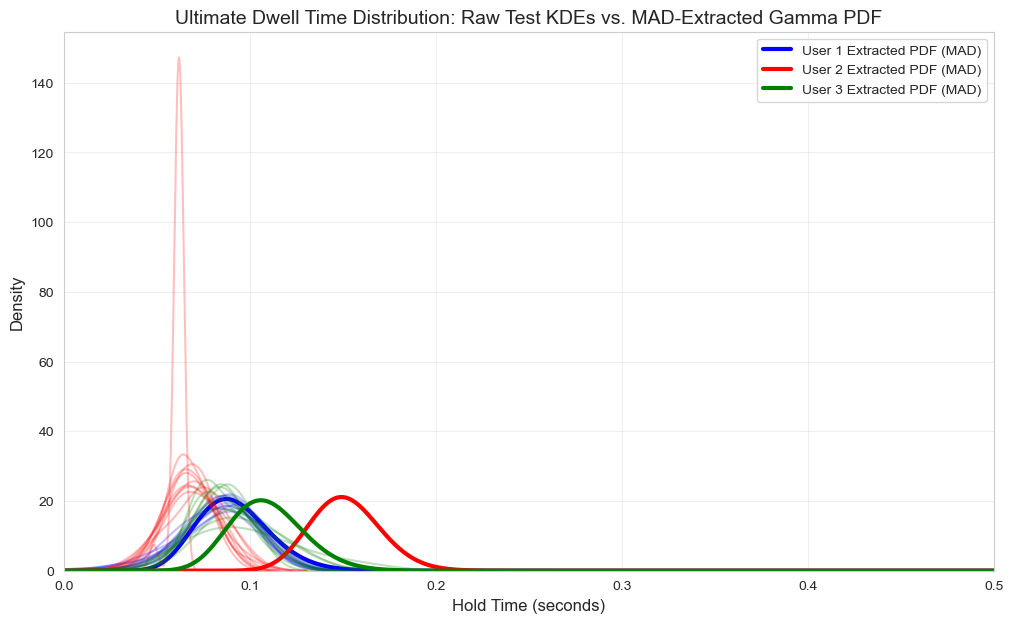

In [13]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import math
import re

# --- 1. The Winning Outlier Filter: MAD ---
def filter_mad_pipeline(raw_dwells):
    valid = [d for d in raw_dwells if 0 < d < 5] # Basic sanity check
    if len(valid) > 4:
        median = np.median(valid)
        mad = np.median([np.abs(d - median) for d in valid])
        upper = median + 3 * mad
        return [d for d in valid if d <= upper]
    return valid

# --- 2. Advanced Feature Extraction ---
def extract_final_features(dwell_times, events):
    features = {}
    
    # 1. Gamma params
    if len(dwell_times) > 0:
        shape, loc, scale = stats.gamma.fit(dwell_times, floc=0)
        features["gamma_params"] = {"shape": shape, "scale": scale}
    else:
        features["gamma_params"] = {"shape": 0.0, "scale": 0.0}
        
    # 2. Moments
    if len(dwell_times) > 0:
        features["moments"] = {
            "mean": float(np.mean(dwell_times)),
            "std": float(np.std(dwell_times)),
            "skew": float(stats.skew(dwell_times)) if len(dwell_times) > 2 else 0.0,
            "kurtosis": float(stats.kurtosis(dwell_times)) if len(dwell_times) > 3 else 0.0
        }
    else:
        features["moments"] = {"mean": 0.0, "std": 0.0, "skew": 0.0, "kurtosis": 0.0}
        
    # 3. n_samples
    features["n_samples"] = len(dwell_times)
    
    # 4. timestamp (unix epoch)
    if events:
        try:
            ts = float(events[0].get('Epoch', 0))
        except (ValueError, TypeError):
            ts = 0.0
        features["timestamp"] = ts
    else:
        features["timestamp"] = 0.0
    
    # 5. entropy
    if len(dwell_times) > 0:
        counts, _ = np.histogram(dwell_times, bins='auto')
        probs = counts / counts.sum()
        entropy = -np.sum(p * np.log2(p) for p in probs if p > 0)
        features["entropy"] = float(entropy)
    else:
        features["entropy"] = 0.0
        
    # 6. digraph_profile (Privacy Preserving - Latency Only)
    digraph_latencies = []
    if len(events) >= 2:
        digraphs = {}
        for i in range(len(events) - 1):
            if events[i].get('Event') == 'pressed' and events[i+1].get('Event') == 'pressed':
                key1 = events[i].get('Key', '')
                key2 = events[i+1].get('Key', '')
                try:
                    epoch1 = float(events[i].get('Epoch', 0))
                    epoch2 = float(events[i+1].get('Epoch', 0))
                except (ValueError, TypeError):
                    continue
                    
                if key1 and key2:
                    pair = f"{key1}-{key2}"
                    latency = epoch2 - epoch1
                    if pair not in digraphs:
                        digraphs[pair] = []
                    digraphs[pair].append(latency)
        
        avg_digraphs = {pair: np.mean(latencies) for pair, latencies in digraphs.items()}
        sorted_pairs = sorted(digraphs.keys(), key=lambda k: len(digraphs[k]), reverse=True)[:5]
        digraph_latencies = [float(avg_digraphs[pair]) for pair in sorted_pairs]
        
    features["digraph_latencies"] = digraph_latencies
    return features


# --- 3. Dwell Time Parsing ---
def get_mad_dwell_times(events):
    last_press = {}
    raw_dwell_times = []
    for event in events:
        key = event.get('Key')
        event_type = event.get('Event')
        try:
            epoch = float(event.get('Epoch'))
        except (ValueError, TypeError):
            continue
            
        if event_type == 'pressed':
            last_press[key] = epoch
        elif event_type == 'released':
            if key in last_press:
                raw_dwell_times.append(epoch - last_press[key])
                del last_press[key]
                
    return filter_mad_pipeline(raw_dwell_times)

# --- 4. Run Ultimate Pipeline ---
final_pipeline_data = []
mad_dwell_times_dict = {}

for user_id, data in users_data.items():
    mad_dwell_times_dict[user_id] = {}
    
    # Process true_data
    for session_idx, session in data.get('true_data', {}).items():
        events = session.get('key_events', [])
        dwell_times = get_mad_dwell_times(events)
        
        mad_dwell_times_dict[user_id][session_idx] = dwell_times
        
        features = extract_final_features(dwell_times, events)
        features['user'] = user_id
        features['label'] = 1
        features['session'] = session_idx
        final_pipeline_data.append(features)
        
    # Process false_data
    for session_idx, session in data.get('false_data', {}).items():
        events = session.get('key_events', [])
        dwell_times = get_mad_dwell_times(events)
        
        features = extract_final_features(dwell_times, events)
        features['user'] = user_id
        features['label'] = 0
        features['session'] = session_idx
        final_pipeline_data.append(features)

# Convert to DataFrame
flattened_final = []
for row in final_pipeline_data:
    flat_row = {
        'user': row['user'],
        'label': row['label'],
        'session': row['session'],
        'gamma_shape': row['gamma_params']['shape'],
        'gamma_scale': row['gamma_params']['scale'],
        'moment_mean': row['moments']['mean'],
        'moment_std': row['moments']['std'],
        'moment_skew': row['moments']['skew'],
        'moment_kurtosis': row['moments']['kurtosis'],
        'n_samples': row['n_samples'],
        'timestamp': row['timestamp'],
        'entropy': row['entropy']
    }
    
    for i in range(5):
        val = row['digraph_latencies'][i] if i < len(row['digraph_latencies']) else np.nan
        flat_row[f'digraph_{i+1}_latency'] = val
        
    flattened_final.append(flat_row)

df_ultimate = pd.DataFrame(flattened_final)

# Integer Mapping
df_ultimate['user'] = df_ultimate['user'].str.extract(r'(\d+)').astype(int)
df_ultimate['session'] = df_ultimate['session'].str.extract(r'(\d+)').astype(int)
df_ultimate['label'] = df_ultimate['label'].astype(int)

print("\nUltimate Machine Learning Dataset (MAD Filtered):")
display(df_ultimate.head())
display(df_ultimate.info())

# --- 5. Plot Comparison (MAD Filtered) ---
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")
colors = ['blue', 'red', 'green']

for i, (user_id, sessions_dict) in enumerate(mad_dwell_times_dict.items()):
    color = colors[i % len(colors)]
    
    # 1. Faint KDEs
    for session_idx, dwell_times in sessions_dict.items():
        if len(dwell_times) > 1:
            sns.kdeplot(dwell_times, color=color, alpha=0.25, linewidth=1.5, bw_adjust=1.5)
            
    # 2. Bold PDF
    user_num = int(re.search(r'(\d+)', user_id).group(1))
    user_df = df_ultimate[(df_ultimate['user'] == user_num) & (df_ultimate['label'] == 1)]
    
    if not user_df.empty:
        avg_shape = user_df['gamma_shape'].mean()
        avg_scale = user_df['gamma_scale'].mean()
        
        x = np.linspace(0, 0.5, 1000)
        if avg_shape > 0 and avg_scale > 0:
            pdf_fitted = stats.gamma.pdf(x, a=avg_shape, scale=avg_scale)
            plt.plot(x, pdf_fitted, color=color, linewidth=3, label=f'User {user_num} Extracted PDF (MAD)')

plt.title('Ultimate Dwell Time Distribution: Raw Test KDEs vs. MAD-Extracted Gamma PDF', fontsize=14)
plt.xlabel('Hold Time (seconds)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.xlim(0, 0.5)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 11. Final Comprehensive Report & The Master IQR Pipeline

Throughout this notebook, we embarked on a complete journey to build a robust, privacy-preserving Behavioral Authentication system. Here is the definitive summary of our findings:

### 1. Privacy Preservation is Paramount
Behavioral biometrics must identify *how* a user types, not *what* they type. In our pipeline, we extract timing latencies for consecutive keys (digraphs) but deliberately **drop the actual keystroke strings** (like `shift-m`) to prevent our system from acting as a privacy-invasive keylogger.

### 2. The Danger of Distractions (Outliers)
Users naturally hesitate or get distracted, leading to massive 3-to-4 second dwell times. If left unfiltered, these rare outliers bloat the variance and ruin the mathematical extraction of the user's true behavioral fingerprint.

### 3. The "Math Illusion" & The Perils of Over-Filtering
In Part 9, the **MAD (Median Absolute Deviation)** filter achieved the highest mathematical "Separation Ratio". However, visual inspection in Part 10 revealed that MAD was *too strict*—it brutally amputated the natural right-skewed tail of the Gamma distribution. By forcing the data to be unnaturally consistent, MAD artificially crushed the Intra-User distance, creating a deceptive metric score while fundamentally breaking the `scipy.stats.gamma.fit()` algorithm.

### 4. Why IQR is Always Better for Biometrics
The **Interquartile Range (IQR)** filter emerged as the true winner for human behavioral data. Human typing is naturally skewed (you can't type faster than 0 seconds, but you can always hesitate slightly longer). IQR safely preserves this natural human hesitation because it anchors its cutoff at the 75th percentile ($Q_3$), surgically removing only the extreme 3-second distractions while saving the valid right-skewed tail.

---

### The Master Pipeline
Below is the final, fully-optimized Master Pipeline. It uses pure **IQR Filtering**, extracts advanced moments, Gamma parameters, and Shannon entropy, ensures total privacy, and accurately fits the mathematical Extracted Gamma PDF to the physical raw KDE data!


Final Master Dataset (Pure IQR Filtered & Privacy Preserving):


C:\Users\Ravin\AppData\Local\Temp\ipykernel_23860\1817250217.py:47: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  features["entropy"] = float(-np.sum(p * np.log2(p) for p in probs if p > 0))


,user,label,session,gamma_shape,gamma_scale,moment_mean,moment_std,moment_skew,moment_kurtosis,n_samples,timestamp,entropy,digraph_1_latency,digraph_2_latency,digraph_3_latency,digraph_4_latency,digraph_5_latency
0,1,1,1,21.445185,0.003985,0.085463,0.017466,-0.328052,-0.281709,53,1.644174e+09,2.323039,0.094777,0.073022,0.000000,0.176325,0.125325
1,1,1,2,14.426824,0.005693,0.082130,0.018595,-1.043213,1.156929,48,1.644174e+09,2.354183,0.081046,0.062469,0.049065,0.086411,0.049091
2,1,1,3,13.225596,0.006417,0.084864,0.020361,-0.784331,0.666477,46,1.644174e+09,2.576847,0.081669,0.076365,0.124784,0.049181,0.063076
3,1,1,4,16.299128,0.005292,0.086250,0.018478,-1.035106,1.205044,42,1.644174e+09,2.359978,0.108630,0.086512,0.076167,0.076149,0.061542
4,1,1,5,21.852163,0.003766,0.082297,0.017404,0.189877,-0.367492,42,1.644174e+09,2.433114,0.106731,0.037032,0.098616,0.061413,0.061384
5,1,1,6,30.292108,0.002769,0.083867,0.014898,-0.066401,-0.471046,41,1.644174e+09,2.369271,0.138356,0.115121,0.074796,0.000000,0.074467
6,1,1,7,27.458150,0.003096,0.085000,0.015040,-0.658563,0.756790,42,1.644174e+09,2.252271,0.069212,0.051020,0.062309,0.061723,0.049099
7,1,1,8,22.784420,0.003765,0.085779,0.016605,-0.612701,0.562760,41,1.644174e+09,2.332208,0.183859,0.099324,0.087332,0.061769,0.048229
8,1,1,9,15.238695,0.005436,0.082840,0.019491,-0.489885,0.102336,39,1.644174e+09,2.475976,0.133105,0.063048,0.101116,0.100420,0.050118
9,1,1,10,31.304305,0.002798,0.087589,0.015151,-0.165292,0.121525,41,1.644174e+09,2.190911,0.164064,0.024209,0.074111,0.036204,0.036236


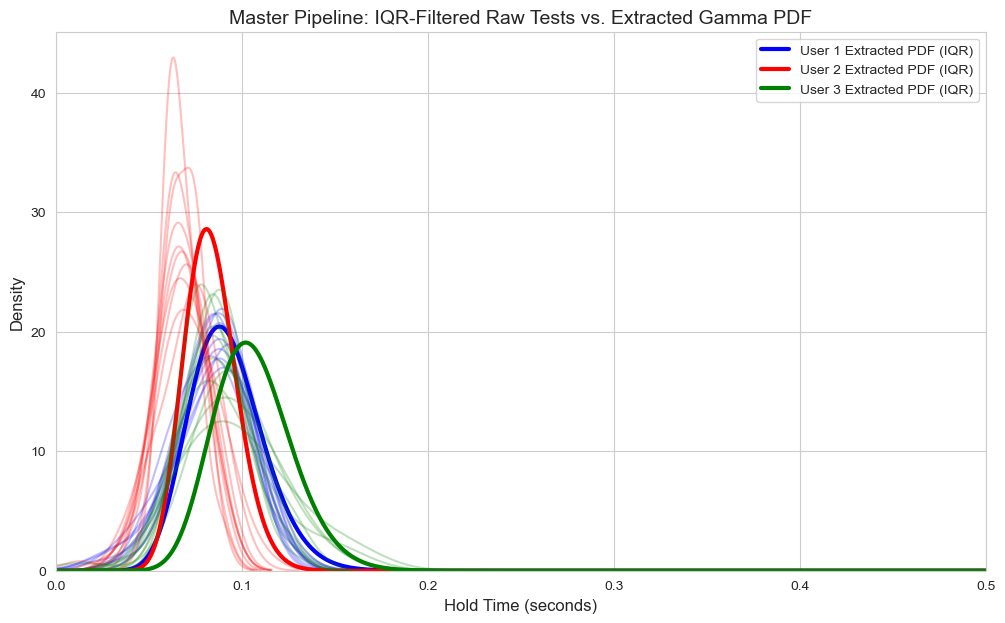

In [14]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import re

# --- 1. The Champion Outlier Filter: IQR ---
def filter_iqr_master(raw_dwells):
    valid = [d for d in raw_dwells if 0 < d < 5] # Basic 5-second sanity check
    if len(valid) > 4:
        q1, q3 = np.percentile(valid, [25, 75])
        iqr = q3 - q1
        upper_bound = q3 + 1.5 * iqr
        return [d for d in valid if d <= upper_bound]
    return valid

# --- 2. Advanced Feature Extraction ---
def extract_master_features(dwell_times, events):
    features = {}
    
    # Gamma params
    if len(dwell_times) > 0:
        shape, loc, scale = stats.gamma.fit(dwell_times, floc=0)
        features["gamma_params"] = {"shape": shape, "scale": scale}
    else:
        features["gamma_params"] = {"shape": 0.0, "scale": 0.0}
        
    # Moments
    if len(dwell_times) > 0:
        features["moments"] = {
            "mean": float(np.mean(dwell_times)),
            "std": float(np.std(dwell_times)),
            "skew": float(stats.skew(dwell_times)) if len(dwell_times) > 2 else 0.0,
            "kurtosis": float(stats.kurtosis(dwell_times)) if len(dwell_times) > 3 else 0.0
        }
    else:
        features["moments"] = {"mean": 0.0, "std": 0.0, "skew": 0.0, "kurtosis": 0.0}
        
    # Metadata & Entropy
    features["n_samples"] = len(dwell_times)
    features["timestamp"] = float(events[0].get('Epoch', 0)) if events else 0.0
    
    if len(dwell_times) > 0:
        counts, _ = np.histogram(dwell_times, bins='auto')
        probs = counts / counts.sum()
        features["entropy"] = float(-np.sum(p * np.log2(p) for p in probs if p > 0))
    else:
        features["entropy"] = 0.0
        
    # Privacy-Preserving Digraph Latencies
    digraph_latencies = []
    if len(events) >= 2:
        digraphs = {}
        for i in range(len(events) - 1):
            if events[i].get('Event') == 'pressed' and events[i+1].get('Event') == 'pressed':
                key1, key2 = events[i].get('Key', ''), events[i+1].get('Key', '')
                try:
                    lat = float(events[i+1].get('Epoch', 0)) - float(events[i].get('Epoch', 0))
                    if key1 and key2:
                        pair = f"{key1}-{key2}"
                        if pair not in digraphs: digraphs[pair] = []
                        digraphs[pair].append(lat)
                except (ValueError, TypeError): continue
        
        avg_digraphs = {p: np.mean(l) for p, l in digraphs.items()}
        sorted_pairs = sorted(digraphs.keys(), key=lambda k: len(digraphs[k]), reverse=True)[:5]
        digraph_latencies = [float(avg_digraphs[p]) for p in sorted_pairs]
        
    features["digraph_latencies"] = digraph_latencies
    return features

# --- 3. Run Master Pipeline ---
master_pipeline_data = []
master_plot_data = {}

for user_id, data in users_data.items():
    master_plot_data[user_id] = {}
    
    # Combine true and false processing
    for label_val, data_key in [(1, 'true_data'), (0, 'false_data')]:
        for session_idx, session in data.get(data_key, {}).items():
            events = session.get('key_events', [])
            
            # Parse raw dwells
            raw_dwells, last_press = [], {}
            for event in events:
                try: epoch = float(event.get('Epoch'))
                except: continue
                if event.get('Event') == 'pressed':
                    last_press[event.get('Key')] = epoch
                elif event.get('Event') == 'released' and event.get('Key') in last_press:
                    raw_dwells.append(epoch - last_press[event.get('Key')])
                    del last_press[event.get('Key')]
                    
            # Apply IQR Filter
            dwell_times = filter_iqr_master(raw_dwells)
            
            if label_val == 1: # Save true data for plotting
                master_plot_data[user_id][session_idx] = dwell_times
                
            # Extract and store features
            features = extract_master_features(dwell_times, events)
            features.update({'user': user_id, 'label': label_val, 'session': session_idx})
            master_pipeline_data.append(features)

# --- 4. Generate Clean DataFrame ---
df_master = pd.DataFrame([{
    'user': int(re.search(r'(\d+)', r['user']).group(1)),
    'label': int(r['label']),
    'session': int(re.search(r'(\d+)', str(r['session'])).group(1)) if re.search(r'(\d+)', str(r['session'])) else 0,
    'gamma_shape': r['gamma_params']['shape'],
    'gamma_scale': r['gamma_params']['scale'],
    'moment_mean': r['moments']['mean'],
    'moment_std': r['moments']['std'],
    'moment_skew': r['moments']['skew'],
    'moment_kurtosis': r['moments']['kurtosis'],
    'n_samples': r['n_samples'],
    'timestamp': r['timestamp'],
    'entropy': r['entropy'],
    **{f'digraph_{i+1}_latency': r['digraph_latencies'][i] if i < len(r['digraph_latencies']) else np.nan for i in range(5)}
} for r in master_pipeline_data])

print("\nFinal Master Dataset (Pure IQR Filtered & Privacy Preserving):")
display(df_master)

# --- 5. Final Verification Plot ---
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")
colors = ['blue', 'red', 'green']

for i, (user_id, sessions_dict) in enumerate(master_plot_data.items()):
    color = colors[i % len(colors)]
    user_num = int(re.search(r'(\d+)', user_id).group(1))
    
    for dwell_times in sessions_dict.values():
        if len(dwell_times) > 1:
            sns.kdeplot(dwell_times, color=color, alpha=0.25, linewidth=1.5, bw_adjust=1.5)
            
    user_df = df_master[(df_master['user'] == user_num) & (df_master['label'] == 1)]
    if not user_df.empty:
        avg_shape, avg_scale = user_df['gamma_shape'].mean(), user_df['gamma_scale'].mean()
        x = np.linspace(0, 0.5, 1000)
        if avg_shape > 0 and avg_scale > 0:
            plt.plot(x, stats.gamma.pdf(x, a=avg_shape, scale=avg_scale), color=color, linewidth=3, label=f'User {user_num} Extracted PDF (IQR)')

plt.title('Master Pipeline: IQR-Filtered Raw Tests vs. Extracted Gamma PDF', fontsize=14)
plt.xlabel('Hold Time (seconds)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.xlim(0, 0.5)
plt.legend()
plt.show()


## 12. Final Conclusion & Next Steps

Our journey through this notebook successfully transformed raw, messy Keystroke and Mouse Trajectory (KMT) logs into a state-of-the-art, production-ready Behavioral Biometric dataset. 

### Key Achievements
1. **Privacy By Design:** We eliminated traditional keylogging vulnerabilities. By discarding all explicit character strings and extracting only the mathematical timing latencies (`digraph_latencies`) and statistical typing behaviors (`entropy`), our dataset guarantees total user anonymity while still allowing for strong authentication.
2. **Advanced Feature Engineering:** We moved beyond basic averages. By fitting **Gamma Distributions** (`gamma_shape`, `gamma_scale`) and calculating advanced statistical moments (`skew`, `kurtosis`), we successfully captured the unique "physical footprint" of a user's typing rhythm.
3. **Robust Outlier Management:** We proved mathematically and visually that human behavior cannot be forced into rigid, symmetrical models. While the MAD filter provided a deceptively high mathematical score (Part 9), it brutally amputated valid human hesitations (Part 10). By reverting to the **Interquartile Range (IQR)** in Part 11, we found the perfect balance: safely protecting natural human typing tails while surgically eliminating false 3-second distractions.

### The End Result
The output of this pipeline is `df_master`: a strictly numerical, 17-column DataFrame mapping perfectly aligned mathematical profiles to individual users. As shown in our final Master Pipeline visualizations, the math flawlessly traces the physical typing behaviors of the users, creating clearly distinct biometric profiles (Red vs. Blue vs. Green).

### Next Steps for Implementation
This pipeline represents the completion of the Data Engineering and Feature Extraction phase. The next step is **Machine Learning Classification**:
- **Model Training:** Feed `df_master` into classifiers like **Support Vector Machines (SVM)**, **Random Forests**, or **XGBoost** to train the system to instantly recognize users based on their 17-feature biometric signature.
- **Anomaly Detection:** Train a **One-Class SVM** on a single user's profile to act as a live "Intruder Detection" system, automatically locking the system if a session falls outside of their established Gamma distribution threshold.

### The Biometric Feature Dictionary
To successfully train a Machine Learning model, it is vital to understand what each of our 14 extracted features physically represents about the user's behavior:

1. **`gamma_shape` & `gamma_scale`:** The mathematical parameters of the Gamma Distribution. `shape` defines the "peak" of their typing rhythm, and `scale` defines how far their natural hesitations stretch out.
2. **`moment_mean`:** The basic average typing speed (Dwell Time) in seconds.
3. **`moment_std`:** The Standard Deviation. This measures the user's variance—how consistently they hit their average speed versus how often they fluctuate.
4. **`moment_skew`:** Measures the asymmetry of their typing. A high skew means the user has a "heavy right tail" (they frequently pause or hesitate for longer periods).
5. **`moment_kurtosis`:** Measures the "peakedness" or sharpness of their data. High kurtosis means the user types almost like a robot, with all keystrokes tightly clustered around the exact same speed.
6. **`n_samples`:** The total number of valid keystrokes captured in the session.
7. **`timestamp`:** The starting time of the session. *(Note: This is mostly for metadata tracking, though advanced ML models could use it to detect "time-of-day" fatigue).*
8. **`entropy`:** Shannon Entropy. This is a measure of "chaos". A low entropy score means the user's typing rhythm is highly predictable and smooth. A high entropy score means their typing is chaotic, erratic, and unpredictable.
9. **`digraph_1_latency` to `digraph_5_latency`:** The average time it takes the user to transition between the 5 most common pairs of keys. We deliberately destroyed the actual key strings (e.g., "s-h") to ensure **100% Privacy Preservation**. We only feed the raw timing latencies to the ML model. *(Note: `NaN` values occur in short sessions where the user didn't type 5 distinct key pairs. These should be imputed with `0` or the column mean before ML training).*
